In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py as h5 
from astropy import units as u
from astropy import constants as c

import scipy
import os

pd.options.display.max_columns = None

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
from matplotlib.ticker import LogLocator, AutoMinorLocator, MultipleLocator
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

rcParams['font.family'] = 'serif'
rcParams["mathtext.fontset"] = 'stix'
rcParams["font.size"] = 13

%config InlineBackend.figure_format='retina' # very useful command for high-res images


In [3]:
colorPalette = {'red': "#E64D4E",
                'orange': "#EE9063",
                'yellow': "#FFDD7B",
                'green': "#77AC54",
                'blue': "#0B92B1",
                'violet': "#665191",
                'gray': "#B4B4B4"
}

In [6]:
st_labels_plot = ['MS', 'MS', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR','CHE',  '--', '--', 'None']
PlotDir = 'paper_plots/'

# Low Mass Grid

COMPAS --random-seed 0  --output-path sim_data --output-container low_mass_grid --initial-mass-1 0.3 --initial-mass-2 0.3 --orbital-period 's[0.5, 1.0, 1.5, 2.0, 2.5, 3.0]' --eccentricity 's[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]' --tides-prescription KAPIL2026  --maximum-evolution-time 13700 --maximum-number-timestep-iterations 1599999

COMPAS --random-seed 0  --output-path sim_data --output-container low_mass_grid_z77 --initial-mass-1 0.3 --initial-mass-2 0.3 --orbital-period 's[0.5, 1.0, 1.5, 2.0, 2.5, 3.0]' --eccentricity 's[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]'  --tides-prescription ZAHN1977 

In [9]:
plot_prefix = 'low_mass_grid_'

In [10]:
DataPath = 'sim_data/low_mass_grid'
df_sanity = pd.read_csv(DataPath+'/sanity_checks.csv')
df_sanity = df_sanity.rename(columns=lambda x: x.strip())

In [11]:
DataPath = 'sim_data/low_mass_grid_z77'
df_sanity_zahn = pd.read_csv(DataPath+'/sanity_checks.csv')
df_sanity_zahn = df_sanity_zahn.rename(columns=lambda x: x.strip())

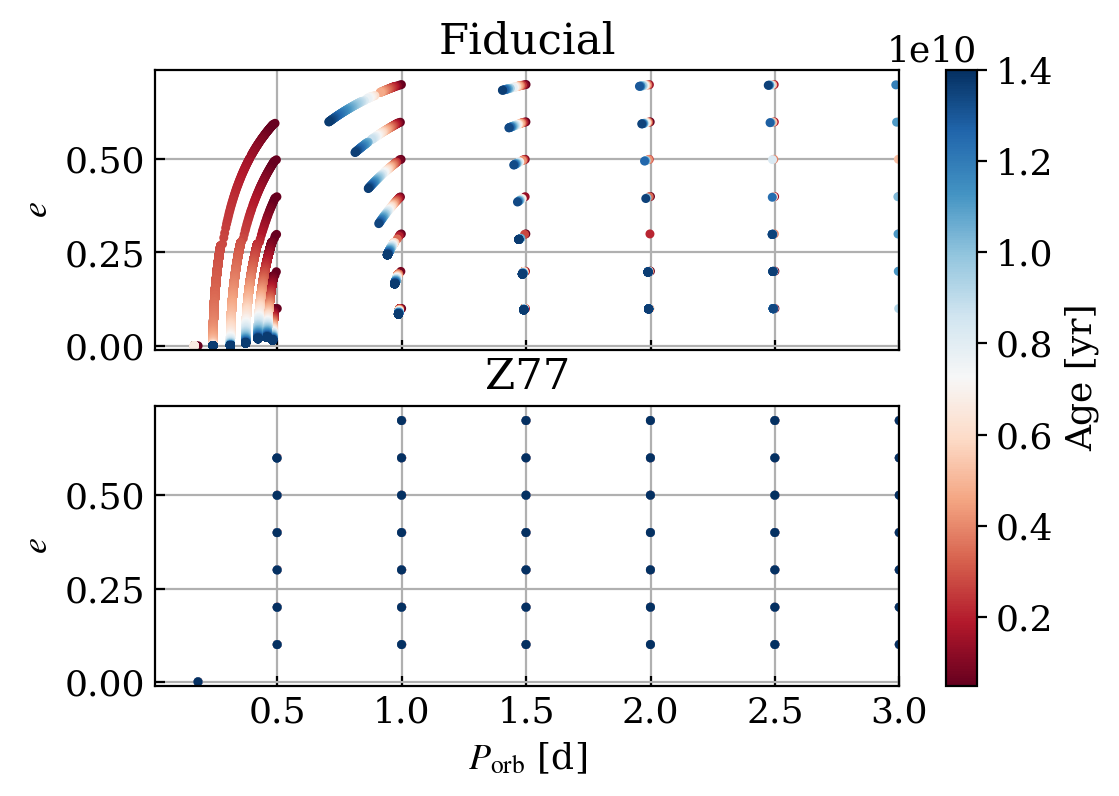

In [13]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors

fig, axes = plt.subplots(figsize=(6, 4), nrows=2, ncols=1, sharex=True)
for ax in axes:
    df = df_sanity_zahn if ax==axes[1] else df_sanity
    title = 'Z77' if ax==axes[1] else 'Fiducial'

    period_orb = 2 * np.pi / df["Omega_before"].values * u.yr.to(u.day) * u.day     # days
    ecc = df["ecc_before"].values                           # 1
    st1 = df["StellarType_1"].values
    Time = df["Time"].values         # Myr

    plt_skip = 50 if ax==axes[0] else 1
    mask = st1>=0
    norm = mcolors.Normalize(vmin=5e8, vmax=1.4e10)
    sc = ax.scatter(period_orb.value[mask][::plt_skip], ecc[mask][::plt_skip], c=(Time*1e6)[mask][::plt_skip], s=5, norm=norm, cmap='RdBu')

    ax.set_ylabel("$e$")
    ax.set_xlim(0.01, 3)
    ax.set_ylim(-0.01, 0.74)
    ax.grid()
    ax.set_axisbelow(True)
    ax.set_title(title)
    ax.tick_params(axis='both', which='both', direction='in')


cbar = fig.colorbar(
        sc,
        ax=axes.ravel().tolist()
    )
cbar.set_label('Age [yr]')

ax.set_xlabel("$P_{\\rm orb}$ [d]")

plt.savefig(PlotDir+plot_prefix+'ecc_vs_Porb_grid_extended_comparison.png', dpi=300, bbox_inches='tight')

plt.show()


# Int Mass Grid

COMPAS --random-seed 0  --output-path sim_data --output-container int_mass_grid --initial-mass-1 1.0 --initial-mass-2 1.0 --orbital-period 's[1.0, 2.0, 3.0, 4.0, 5.0, 7.5, 10.0,  12.5, 15.0, 17.5, 20.0, 22.5, 25.0]' --eccentricity 's[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]' --tides-prescription KAPIL2026 --maximum-evolution-time 13700 --maximum-number-timestep-iterations 13999 --timestep-multiplier 50.0

COMPAS --random-seed 0  --output-path sim_data --output-container int_mass_grid_z77 --initial-mass-1 1.0 --initial-mass-2 1.0 --orbital-period 's[1.0, 2.0, 3.0, 4.0, 5.0, 7.5, 10.0,  12.5, 15.0, 17.5, 20.0, 22.5, 25.0]' --eccentricity 's[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]' --tides-prescription ZAHN1977

In [15]:
plot_prefix = 'int_mass_grid_'

In [16]:
DataPath = 'sim_data/int_mass_grid'
df_sanity = pd.read_csv(DataPath+'/sanity_checks.csv')
df_sanity = df_sanity.rename(columns=lambda x: x.strip())

In [17]:
DataPath = 'sim_data/int_mass_grid_z77'
df_sanity_zahn = pd.read_csv(DataPath+'/sanity_checks.csv')
df_sanity_zahn = df_sanity_zahn.rename(columns=lambda x: x.strip())

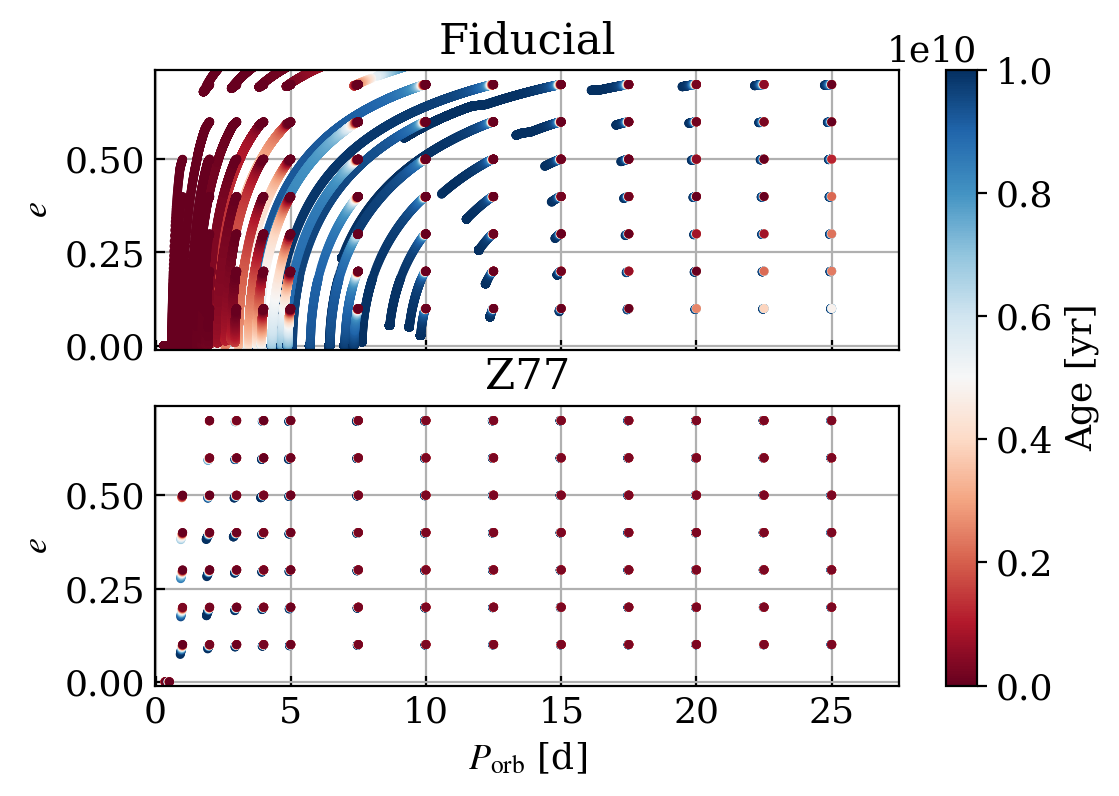

In [18]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors

fig, axes = plt.subplots(figsize=(6, 4), nrows=2, ncols=1, sharex=True)
for ax in axes:
    df = df_sanity_zahn if ax==axes[1] else df_sanity
    title = 'Z77' if ax==axes[1] else 'Fiducial'

    period_orb = 2 * np.pi / df["Omega_before"].values * u.yr.to(u.day) * u.day     # days
    ecc = df["ecc_before"].values                           # 1
    st1 = df["StellarType_1"].values
    Time = df["Time"].values         # Myr

    plt_skip = -5
    mask = st1<=2
    # norm = LogNorm(vmin=1.6e9, vmax=1.4e10)
    norm = mcolors.Normalize(vmin=0e10, vmax=1.0e10)
    sc = ax.scatter(period_orb.value[mask][::plt_skip], ecc[mask][::plt_skip], c=(Time*1e6)[mask][::plt_skip], s=5, norm=norm, cmap='RdBu')

    ax.set_ylabel("$e$")
    # ax.set_xscale('log')
    ax.set_xlim(-0.01, 27.5)
    ax.set_ylim(-0.01, 0.74)
    ax.grid()
    ax.set_axisbelow(True)
    ax.set_title(title)
    ax.tick_params(axis='both', which='both', direction='in')


cbar = fig.colorbar(
        sc,
        ax=axes.ravel().tolist()
    )
cbar.set_label('Age [yr]')

ax.set_xlabel("$P_{\\rm orb}$ [d]")

plt.savefig(PlotDir+plot_prefix+'ecc_vs_Porb_grid_extended_comparison.png', dpi=300, bbox_inches='tight')

plt.show()


# High Mass MS Grid

In [ ]:
plot_prefix = 'high_mass_ms_grid_'

In [ ]:
DataPath = 'sim_data/high_mass_ms_grid'
df_sanity = pd.read_csv(DataPath+'/sanity_checks.csv')
df_sanity = df_sanity.rename(columns=lambda x: x.strip())

In [ ]:
DataPath = 'sim_data/high_mass_ms_grid_z77'
df_sanity_zahn = pd.read_csv(DataPath+'/sanity_checks.csv')
df_sanity_zahn = df_sanity_zahn.rename(columns=lambda x: x.strip())

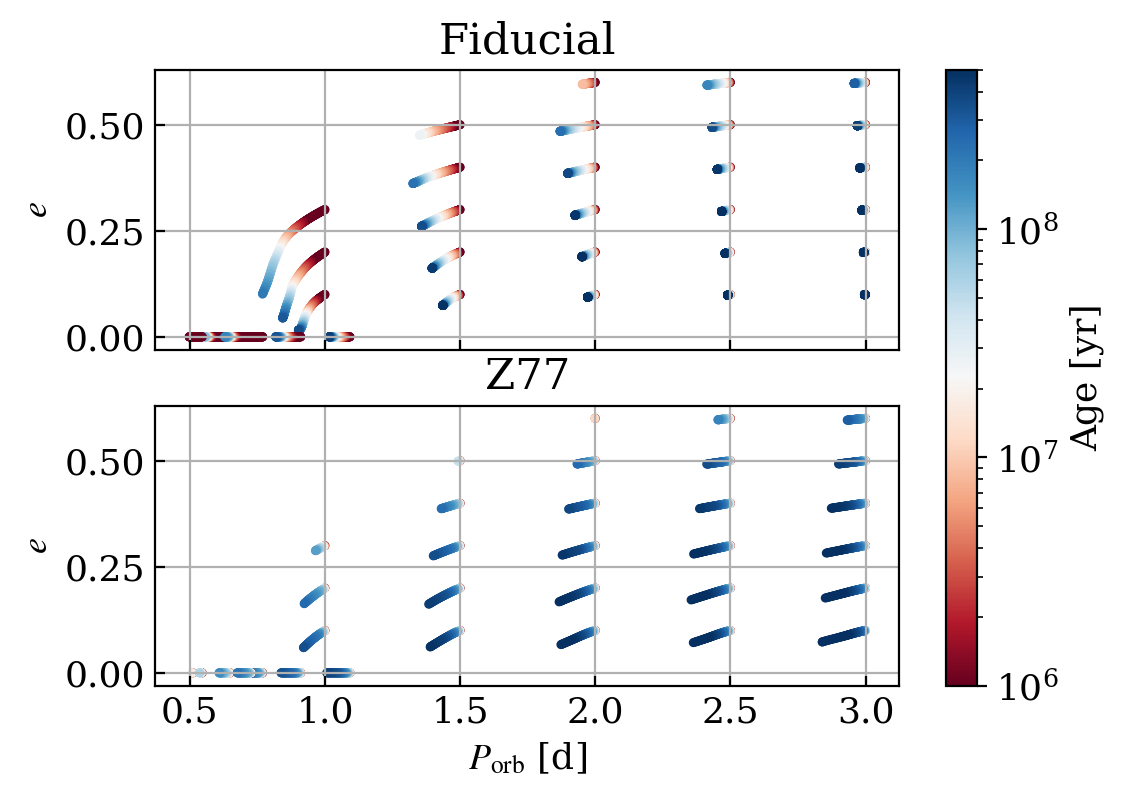

In [24]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors

fig, axes = plt.subplots(figsize=(6, 4), nrows=2, ncols=1, sharex=True)
for ax in axes:
    df = df_sanity_zahn if ax==axes[1] else df_sanity
    title = 'Z77' if ax==axes[1] else 'Fiducial'

    period_orb = 2 * np.pi / df["Omega_before"].values * u.yr.to(u.day) * u.day     # days
    ecc = df["ecc_before"].values                           # 1
    st1 = df["StellarType_1"].values
    Time = df["Time"].values         # Myr

    plt_skip = 1
    mask = st1<=1
    sc = ax.scatter(period_orb.value[mask][::plt_skip], ecc[mask][::plt_skip], c=(Time*1e6)[mask][::plt_skip], s=5, norm=LogNorm(vmin=1e6, vmax=5e8), cmap='RdBu')

    ax.set_ylabel("$e$")
    # ax.set_xscale('log')
    # ax.set_xlim(2030, 29000)
    ax.grid()
    ax.set_title(title)
    ax.tick_params(axis='both', which='both', direction='in')


cbar = fig.colorbar(
        sc,
        ax=axes.ravel().tolist()
    )
cbar.set_label('Age [yr]')

ax.set_xlabel("$P_{\\rm orb}$ [d]")

plt.savefig(PlotDir+plot_prefix+'ecc_vs_Porb_grid_extended_comparison.png', dpi=300, bbox_inches='tight')

plt.show()


/var/folders/wj/l7fs8hg555n8nzz7myk9cysw0000gn/T/ipykernel_83124/2123946022.py:11: RuntimeWarning: divide by zero encountered in divide
  period_spin = 2 * np.pi / df["Omega1_before"].values * u.yr.to(u.day) * u.day     # days


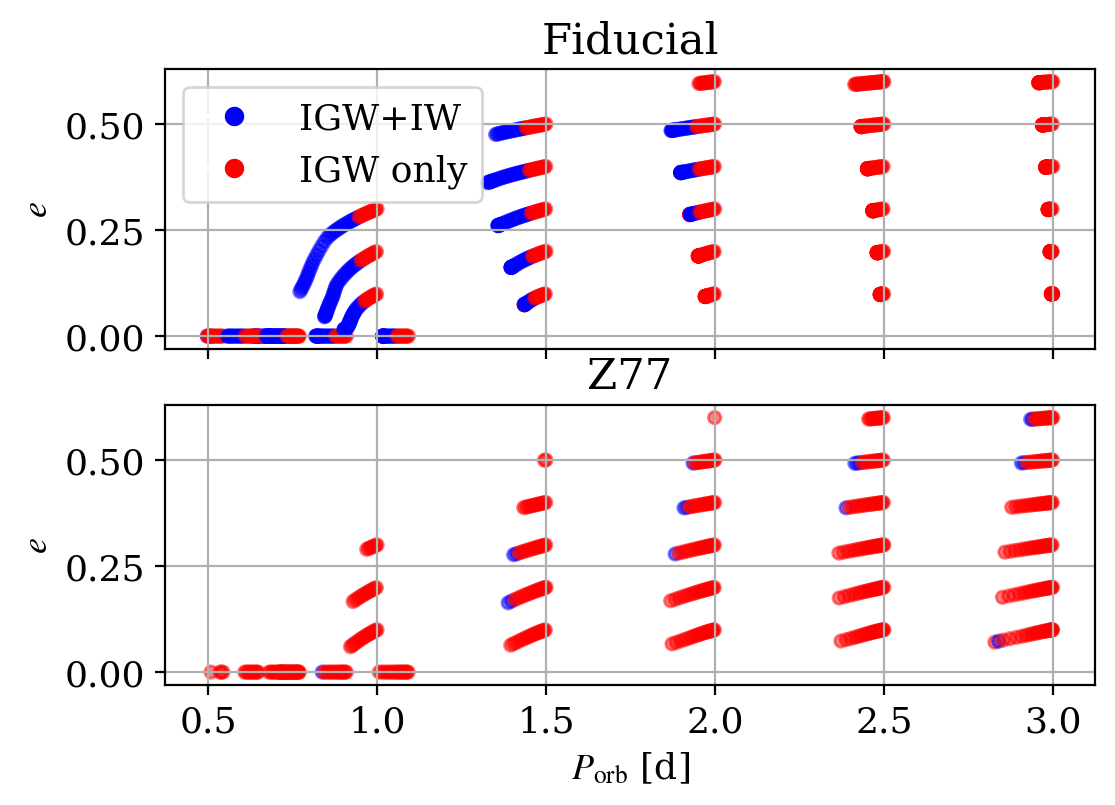

In [25]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors

fig, axes = plt.subplots(figsize=(6, 4), nrows=2, ncols=1, sharex=True)
for ax in axes:
    df = df_sanity_zahn if ax==axes[1] else df_sanity
    title = 'Z77' if ax==axes[1] else 'Fiducial'

    period_orb = 2 * np.pi / df["Omega_before"].values * u.yr.to(u.day) * u.day     # days
    period_spin = 2 * np.pi / df["Omega1_before"].values * u.yr.to(u.day) * u.day     # days

    colors_ratio = ['b' if (2 * df["Omega1_before"].values[i] > df["Omega_before"].values[i]) else 'r' for i in range(len(df))]
    ecc = df["ecc_before"].values                           # 1

    norm = mcolors.Normalize(vmin=0.0, vmax=3.0)
    plt_skip = 5
    sc = ax.scatter(
        period_orb.value[::-1][::plt_skip],
        ecc[::-1][::plt_skip],
        c=colors_ratio[::-1][::plt_skip],
        s=20,
        alpha=0.5
    )

    ax.set_ylabel("$e$")
    # ax.set_xscale('log')
    # ax.set_xlim(2030, 29000)
    ax.grid()
    ax.set_title(title)
    if ax == axes[0]:
        legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label='IGW+IW', markerfacecolor='b', markersize=8),
                       plt.Line2D([0], [0], marker='o', color='w', label='IGW only', markerfacecolor='r', markersize=8)]
        ax.legend(handles=legend_elements, loc='upper left')

ax.set_xlabel("$P_{\\rm orb}$ [d]")

plt.show()


# High Mass ABG Grid

In [ ]:
plot_prefix = 'high_mass_agb_grid_'

In [ ]:
DataPath = 'sim_data/high_mass_agb_grid'
df_sanity = pd.read_csv(DataPath+'/sanity_checks.csv')
df_sanity = df_sanity.rename(columns=lambda x: x.strip())

In [ ]:
DataPath = 'sim_data/high_mass_agb_grid_z77'
df_sanity_zahn = pd.read_csv(DataPath+'/sanity_checks.csv')
df_sanity_zahn = df_sanity_zahn.rename(columns=lambda x: x.strip())

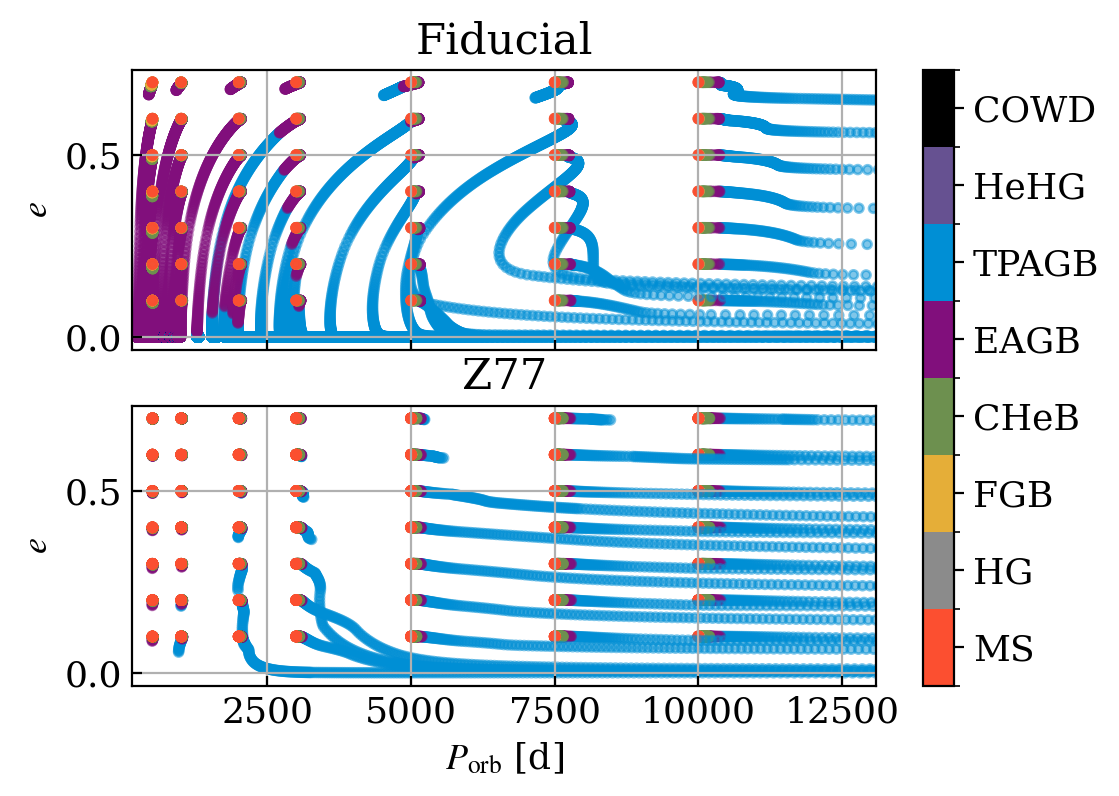

In [27]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors

fig, axes = plt.subplots(figsize=(6, 4), nrows=2, ncols=1, sharex=True)
for ax in axes:
    df = df_sanity_zahn if ax==axes[1] else df_sanity
    title = 'Z77' if ax==axes[1] else 'Fiducial'

    unique_vals = np.array([ 1,  2,  3,  4,  5,  6,  8, 11])
    K = len(unique_vals)

    labels_for_colorbar = [st_labels_plot[v] for v in unique_vals]

    colors = ['#fc4f30', '#8b8b8b', '#e5ae38', '#6d904f', '#810f7c', '#008fd5', '#665191','#000000']
    base_cmap = mcolors.ListedColormap(colors[::-1], name='fivethirtyeight_discrete')


    colors_opaque = base_cmap(np.linspace(1, 0, K))
    colors_opaque[:, -1] = 1.0
    cmap_opaque = ListedColormap(colors_opaque)

    # --- FIXED BOUNDARIES FOR TRUE DISCRETE VALUES ---
    bounds = np.append(unique_vals - 0.5, unique_vals[-1] + 0.5)
    norm = BoundaryNorm(bounds, K)

    period_orb = 2 * np.pi / df["Omega_before"].values * u.yr.to(u.day) * u.day     # days
    ecc = df["ecc_before"].values                           # 1
    st1 = df["StellarType_1"].values

    plt_skip = 5
    sc = ax.scatter(
        period_orb.value[::-1][::plt_skip],
        ecc[::-1][::plt_skip],
        c=st1[::-1][::plt_skip],
        cmap=cmap_opaque,
        norm=norm,
        s=10,
        alpha=0.5
    )

    sm = ScalarMappable(norm=norm, cmap=cmap_opaque)
    sm.set_array([])

    ax.set_ylabel("$e$")
    ax.set_xlim(150, 13100)
    ax.grid()
    ax.set_title(title)
    ax.tick_params(axis='both', which='both', direction='in')


cbar = fig.colorbar(
        sm,
        ax=axes.ravel().tolist(),
        boundaries=bounds,
        ticks=[1, 2, 3, 4, 5, 6.5, 9, 11]
    )

cbar.ax.set_yticklabels(labels_for_colorbar)
ax.set_xlabel("$P_{\\rm orb}$ [d]")

plt.savefig(PlotDir+plot_prefix+'ecc_vs_Porb_grid_extended_comparison.png', dpi=300, bbox_inches='tight')

plt.show()


/var/folders/wj/l7fs8hg555n8nzz7myk9cysw0000gn/T/ipykernel_83124/3013747243.py:11: RuntimeWarning: divide by zero encountered in divide
  period_spin = 2 * np.pi / df["Omega1_before"].values * u.yr.to(u.day) * u.day     # days


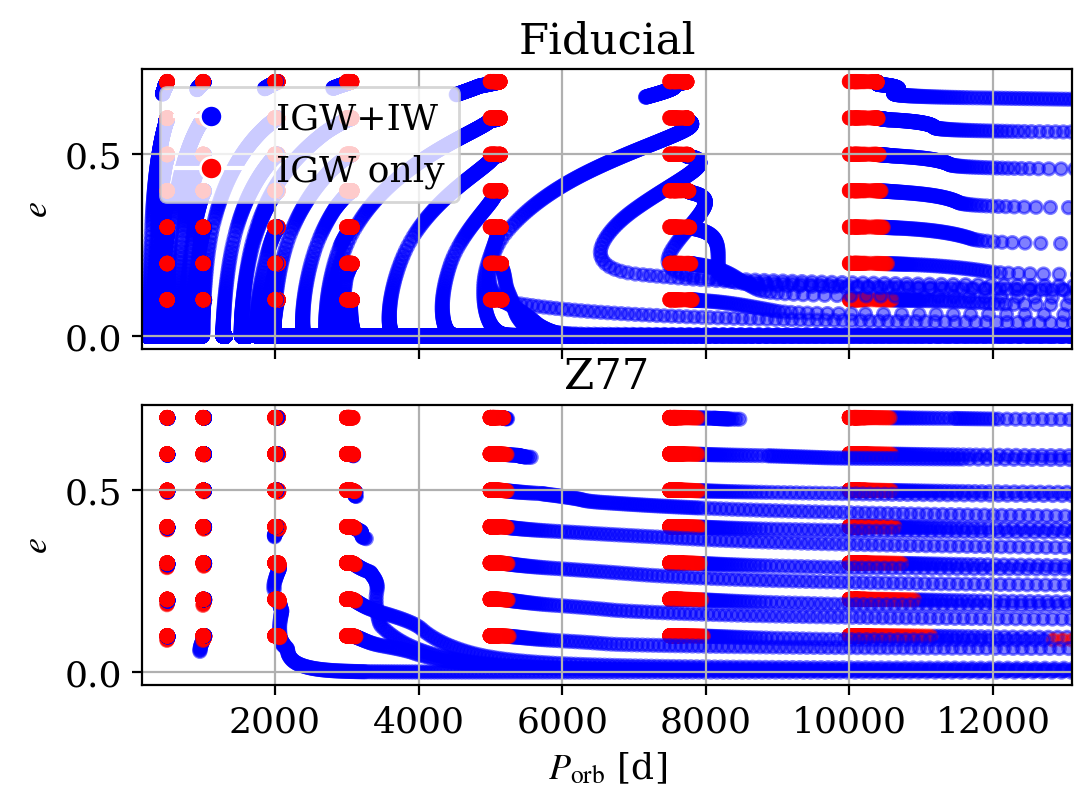

In [28]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors

fig, axes = plt.subplots(figsize=(6, 4), nrows=2, ncols=1, sharex=True)
for ax in axes:
    df = df_sanity_zahn if ax==axes[1] else df_sanity
    title = 'Z77' if ax==axes[1] else 'Fiducial'

    period_orb = 2 * np.pi / df["Omega_before"].values * u.yr.to(u.day) * u.day     # days
    period_spin = 2 * np.pi / df["Omega1_before"].values * u.yr.to(u.day) * u.day     # days

    colors_ratio = ['b' if (2 * df["Omega1_before"].values[i] > df["Omega_before"].values[i]) else 'r' for i in range(len(df))]
    ecc = df["ecc_before"].values                           # 1

    norm = mcolors.Normalize(vmin=0.0, vmax=3.0)
    plt_skip = 5
    sc = ax.scatter(
        period_orb.value[::-1][::plt_skip],
        ecc[::-1][::plt_skip],
        c=colors_ratio[::-1][::plt_skip],
        s=20,
        alpha=0.5
    )

    ax.set_ylabel("$e$")
    # ax.set_xscale('log')
    ax.set_xlim(150, 13100)
    ax.grid()
    ax.set_title(title)
    if ax == axes[0]:
        legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label='IGW+IW', markerfacecolor='b', markersize=8),
                       plt.Line2D([0], [0], marker='o', color='w', label='IGW only', markerfacecolor='r', markersize=8)]
        ax.legend(handles=legend_elements, loc='upper left')

ax.set_xlabel("$P_{\\rm orb}$ [d]")

plt.show()
